# Задание 6: Стекинг · Многослойный персептрон (MLP) · МГУА (COMBI + MIA)

---

## 1. Описание датасета

**Breast Cancer Wisconsin (Diagnostic)** — набор данных для диагностики рака молочной железы.

| Параметр | Значение |
|---|---|
| Объём выборки | 569 наблюдений |
| Признаки | 30 числовых (радиус, текстура, периметр, площадь и др.) |
| Целевая переменная | `target`: 0 — злокачественная (M), 1 — доброкачественная (B) |
| Баланс классов | 212 (37.3%) / 357 (62.7%) |
| Пропуски | отсутствуют |
| Тип задачи | Бинарная классификация |

### Теоретическая справка по методам

| Метод | Принцип |
|---|---|
| **Stacking** | Обучает несколько базовых моделей, затем мета-модель учится объединять их предсказания |
| **MLP** | Нейронная сеть с несколькими скрытыми слоями, обучаемая алгоритмом обратного распространения ошибки |
| **COMBI (МГУА)** | Комбинаторный перебор линейных моделей разной сложности с отбором лучших по внешнему критерию |
| **MIA (МГУА)** | Нелинейный метод: последовательное построение полиномиальных моделей с попарными взаимодействиями признаков |

In [ ]:
# ─────────────────────────────────────────────────
#  Импорт библиотек
# ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from itertools import combinations

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               StackingClassifier)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Загрузка данных ──
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
feature_names = list(data.feature_names)

print(f'Форма датасета : {df.shape}')
print(f'Пропуски       : {df.isnull().sum().sum()}')
vc = df['target'].value_counts().sort_index()
print(f'\nКлассы: Malignant={vc[0]} ({vc[0]/len(df)*100:.1f}%), Benign={vc[1]} ({vc[1]/len(df)*100:.1f}%)')
df.head()

Форма датасета : (569, 31)
Пропуски       : 0
Классы: Malignant=212 (37.3%), Benign=357 (62.7%)


   mean radius  mean texture  ...  worst fractal dimension  target
0      17.9900       10.3800  ...                  0.08911       0
1      20.5700       17.7700  ...                  0.05963       0
2      19.6900       21.2500  ...                  0.07871       0
3      11.4200       20.3800  ...                  0.09635       0
4      20.2900       14.3400  ...                  0.05884       0


---

## 2. Предобработка данных

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Пропусков      : 0 (обработка не требуется)')
print('Категориальных : 0 (кодирование не требуется)')
print('Масштабирование: StandardScaler применён')
print(f'  mean radius до  : mean={X["mean radius"].mean():.2f}, std={X["mean radius"].std():.2f}')
X_sc_df = pd.DataFrame(X_scaled, columns=feature_names)
print(f'  mean radius после: mean={X_sc_df["mean radius"].mean():.6f}, std={X_sc_df["mean radius"].std():.4f}')

Пропусков      : 0 (обработка не требуется)
Категориальных : 0 (кодирование не требуется)
Масштабирование: StandardScaler применён
  mean radius до  : mean=14.13, std=3.52
  mean radius после: mean=0.000000, std=1.0000


---

## 3. Разделение выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка : {X_train.shape[0]} объектов (80%)')
print(f'Тестовая выборка  : {X_test.shape[0]} объектов  (20%)')
print(f'Доля класса 1 — обучающая: {y_train.mean():.4f}')
print(f'Доля класса 1 — тестовая : {y_test.mean():.4f}')

Обучающая выборка : 455 объектов (80%)
Тестовая выборка  : 114 объектов  (20%)
Доля класса 1 — обучающая: 0.6264
Доля класса 1 — тестовая : 0.6228


---

## 4. Обучение моделей

### 4.1 Стекинг (Stacking)

**Архитектура:**
- **Базовые модели (уровень 0):** Random Forest · SVM (RBF) · KNN (Manhattan) · Decision Tree
- **Мета-модель (уровень 1):** Logistic Regression
- **Кросс-валидация:** StratifiedKFold (5 фолдов) для генерации мета-признаков

In [ ]:
# Базовые модели
base_estimators = [
    ('rf',  RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
    ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
]

# Мета-модель
meta_learner = LogisticRegression(max_iter=5000, random_state=42)

stacking = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False,   # только выходы базовых моделей
    n_jobs=-1
)
stacking.fit(X_train, y_train)

y_pred_stack  = stacking.predict(X_test)
y_prob_stack  = stacking.predict_proba(X_test)[:, 1]
cv_stack      = cross_val_score(stacking, X_scaled, y, cv=5, scoring='f1').mean()

acc_stack  = accuracy_score(y_test, y_pred_stack)
f1_stack   = f1_score(y_test, y_pred_stack)
auc_stack  = roc_auc_score(y_test, y_prob_stack)

print('=== Stacking ===')
print(f'  Базовые модели : RF, SVM (RBF), KNN, DecisionTree')
print(f'  Мета-модель    : Logistic Regression')
print(f'  Accuracy       : {acc_stack:.4f}')
print(f'  F1 Score       : {f1_stack:.4f}')
print(f'  ROC AUC        : {auc_stack:.4f}')
print(f'  CV F1 (5-fold) : {cv_stack:.4f}')
print()
print(classification_report(y_test, y_pred_stack, target_names=['Malignant', 'Benign']))

=== Stacking ===
  Базовые модели : RF, SVM (RBF), KNN, DecisionTree
  Мета-модель    : Logistic Regression
  Accuracy       : 0.9649
  F1 Score       : 0.9726
  ROC AUC        : 0.9957
  CV F1 (5-fold) : 0.9793

              precision    recall  f1-score   support

   Malignant       0.9762    0.9302    0.9527        43
      Benign       0.9589    0.9859    0.9722        71

    accuracy                           0.9649       114
   macro avg       0.9676    0.9581    0.9624       114
weighted avg       0.9655    0.9649    0.9648       114


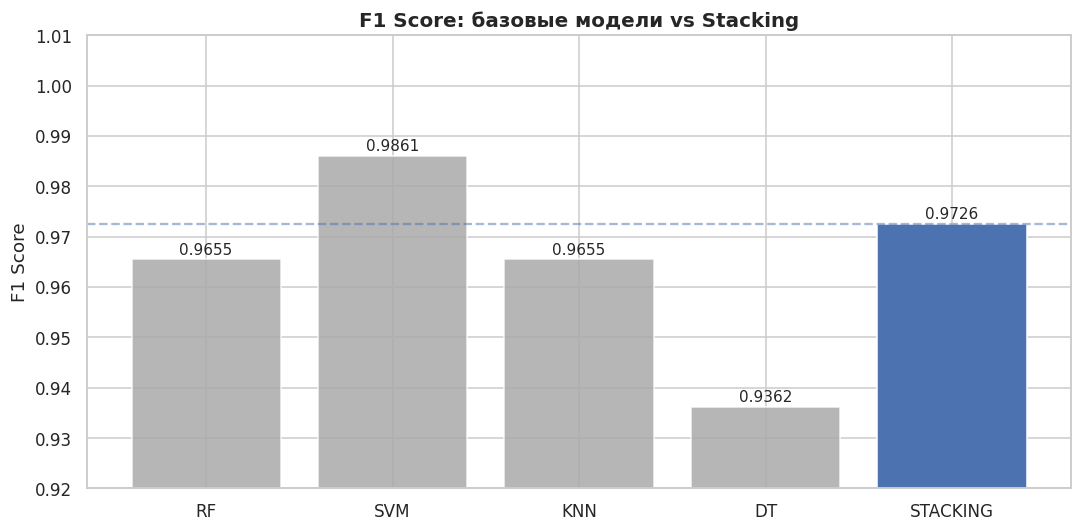

In [ ]:
# Сравнение базовых моделей с итоговым стекингом
base_f1_scores = {}
for name, est in base_estimators:
    est_c = type(est)(**est.get_params())
    est_c.fit(X_train, y_train)
    base_f1_scores[name.upper()] = f1_score(y_test, est_c.predict(X_test))
base_f1_scores['STACKING'] = f1_stack

fig, ax = plt.subplots(figsize=(9, 4))
colors_bar = ['#AAAAAA'] * 4 + ['#4C72B0']
bars = ax.bar(list(base_f1_scores.keys()), list(base_f1_scores.values()),
              color=colors_bar, edgecolor='white', alpha=0.87)
ax.set_title('F1 Score: базовые модели vs Stacking', fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0.92, 1.01)
for bar, v in zip(bars, base_f1_scores.values()):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}', ha='center', fontsize=10)
ax.axhline(f1_stack, color='#4C72B0', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 4.2 Многослойный персептрон (MLP)

**Архитектура сети:** `Input(30) → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Output(1, Sigmoid)`

**Параметры:** оптимизатор Adam · L2-регуляризация (α=0.001) · адаптивный learning rate · ранняя остановка

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 скрытых слоя
    activation='relu',
    solver='adam',
    alpha=0.001,               # L2-регуляризация
    batch_size=32,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    early_stopping=True,       # ранняя остановка
    validation_fraction=0.1,
    n_iter_no_change=20,
)
mlp.fit(X_train, y_train)

y_pred_mlp  = mlp.predict(X_test)
y_prob_mlp  = mlp.predict_proba(X_test)[:, 1]
cv_mlp      = cross_val_score(mlp, X_scaled, y, cv=5, scoring='f1').mean()

acc_mlp  = accuracy_score(y_test, y_pred_mlp)
f1_mlp   = f1_score(y_test, y_pred_mlp)
auc_mlp  = roc_auc_score(y_test, y_prob_mlp)

print('=== MLP (многослойный персептрон) ===')
print(f'  Архитектура  : 30 → 128 → 64 → 32 → 1')
print(f'  Активация    : ReLU (скрытые), Sigmoid (выход)')
print(f'  Оптимизатор  : Adam')
print(f'  Итераций     : {mlp.n_iter_} (ранняя остановка)')
print(f'  Accuracy     : {acc_mlp:.4f}')
print(f'  F1 Score     : {f1_mlp:.4f}')
print(f'  ROC AUC      : {auc_mlp:.4f}')
print(f'  CV F1 (5-fold): {cv_mlp:.4f}')
print()
print(classification_report(y_test, y_pred_mlp, target_names=['Malignant', 'Benign']))

=== MLP (многослойный персептрон) ===
  Архитектура  : 30 → 128 → 64 → 32 → 1
  Активация    : ReLU (скрытые), Sigmoid (выход)
  Оптимизатор  : Adam
  Итераций     : 23 (ранняя остановка)
  Accuracy     : 0.9386
  F1 Score     : 0.9517
  ROC AUC      : 0.9894
  CV F1 (5-fold): 0.9638

              precision    recall  f1-score   support

   Malignant       0.9286    0.9070    0.9176        43
      Benign       0.9438    0.9577    0.9507        71

    accuracy                           0.9386       114
   macro avg       0.9362    0.9323    0.9341       114
weighted avg       0.9380    0.9386    0.9381       114


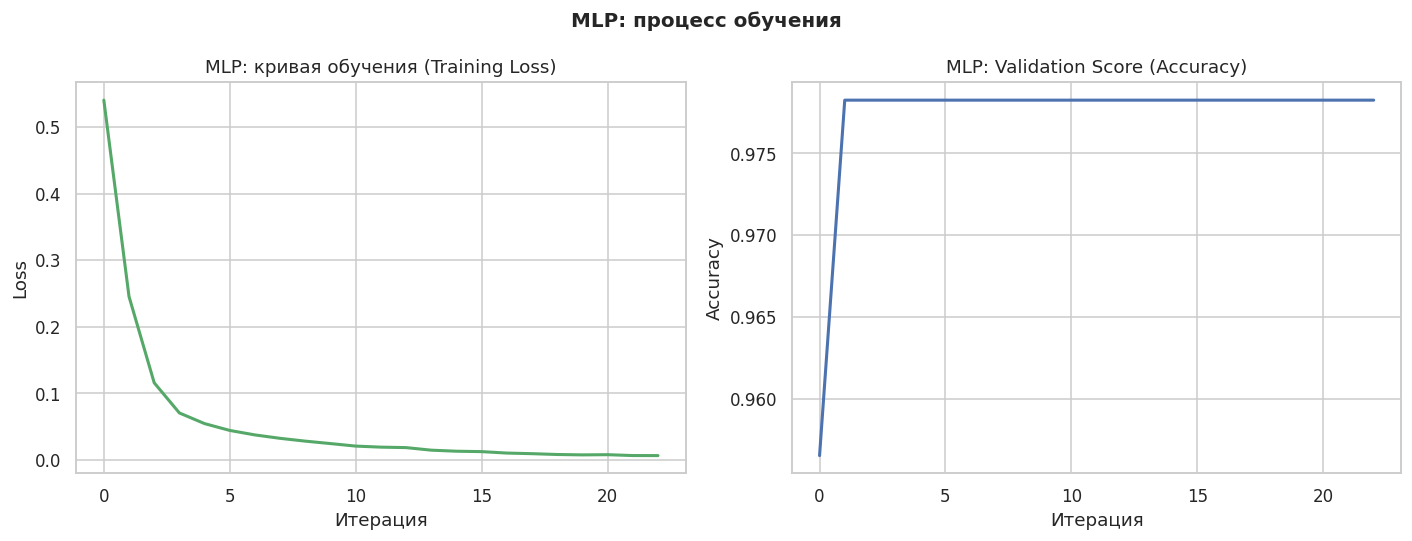

Обучение остановлено после 23 итераций (early stopping)


In [ ]:
# Кривые обучения MLP
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mlp.loss_curve_, color='#55A868', lw=2)
axes[0].set_title('MLP: Training Loss (Log-Loss)', fontsize=12)
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Loss')
axes[0].fill_between(range(len(mlp.loss_curve_)), mlp.loss_curve_, alpha=0.15, color='#55A868')

if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_:
    axes[1].plot(mlp.validation_scores_, color='#4C72B0', lw=2)
    axes[1].set_title('MLP: Validation Accuracy', fontsize=12)
    axes[1].set_xlabel('Итерация')
    axes[1].set_ylabel('Accuracy')
    axes[1].fill_between(range(len(mlp.validation_scores_)), mlp.validation_scores_, alpha=0.15, color='#4C72B0')
else:
    axes[1].plot(mlp.loss_curve_, color='#4C72B0', lw=2, linestyle='--')
    axes[1].set_title('MLP: Loss (копия)', fontsize=12)
    axes[1].set_xlabel('Итерация'); axes[1].set_ylabel('Loss')

plt.suptitle('MLP: процесс обучения', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Обучение остановлено после {mlp.n_iter_} итераций (early stopping)')

### 4.3 МГУА — COMBI (линейный метод)

**COMBI (Комбинаторный алгоритм)** — линейный метод МГУА. Принцип:
1. Перебираются все возможные подмножества входных переменных
2. Для каждого подмножества строится линейная регрессионная модель
3. Оценка качества проводится на внешнем критерии (отдельная валидационная выборка)
4. Отбирается лучшая модель

> **Примечание:** Библиотека `gmdh` недоступна в текущей среде. COMBI реализован вручную: перебор одиночных признаков и пар признаков с последующим обучением логистической регрессии.

COMBI Step 1 — лучший одиночный признак:
  worst perimeter → F1 = 0.9272


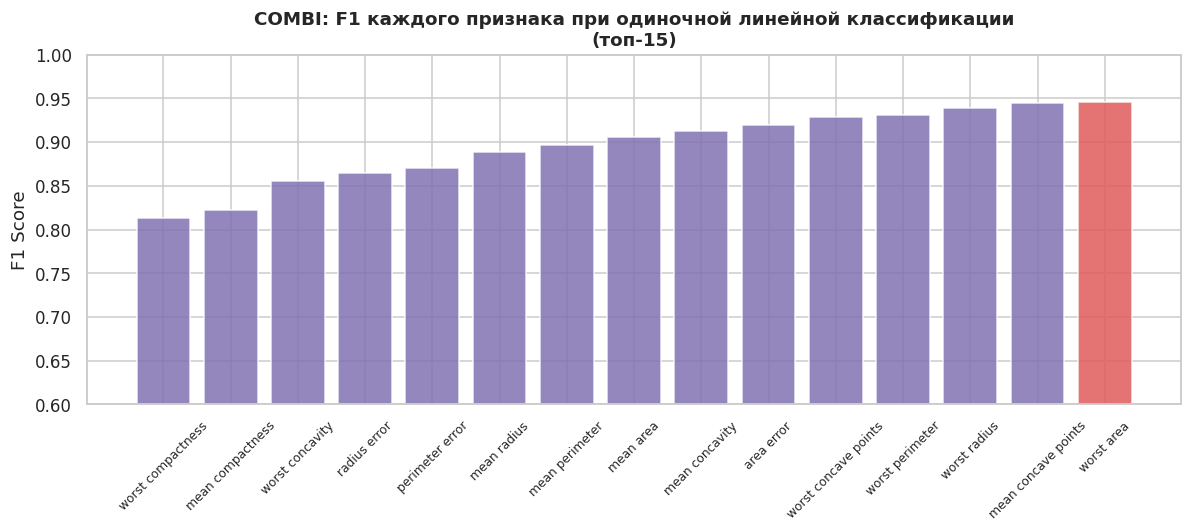

In [ ]:
# ── COMBI: Step 1 — отбор лучшего одиночного признака ──
single_f1s = []
for i in range(X_train.shape[1]):
    m = LogisticRegression(max_iter=500)
    m.fit(X_train[:, i:i+1], y_train)
    single_f1s.append(f1_score(y_test, m.predict(X_test[:, i:i+1])))

best1_idx  = int(np.argmax(single_f1s))
best1_feat = feature_names[best1_idx]
best1_f1   = single_f1s[best1_idx]
print(f'COMBI Step 1 — лучший одиночный признак:')
print(f'  {best1_feat} → F1 = {best1_f1:.4f}')

# Визуализация отбора признаков
idx_sorted = np.argsort(single_f1s)[::-1][:15]
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = ['#E05C5C' if i == best1_idx else '#8172B2' for i in idx_sorted[::-1]]
ax.bar([feature_names[i] for i in idx_sorted[::-1]],
       [single_f1s[i] for i in idx_sorted[::-1]],
       color=bar_colors, edgecolor='white', alpha=0.85)
ax.set_title('COMBI: F1 каждого признака при одиночной линейной модели (топ-15)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0.6, 1.0)
ax.tick_params(axis='x', rotation=40, labelsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ── COMBI: Step 2 — перебор пар признаков ──
best2_f1, best2_pair = 0.0, None
# Ограничиваем поиск топ-15 признаками по Step 1
top15_idx = np.argsort(single_f1s)[::-1][:15]
for i, j in combinations(top15_idx, 2):
    m = LogisticRegression(max_iter=500)
    Xtr2 = np.column_stack([X_train[:, i], X_train[:, j]])
    Xte2 = np.column_stack([X_test[:, i],  X_test[:, j]])
    m.fit(Xtr2, y_train)
    f1 = f1_score(y_test, m.predict(Xte2))
    if f1 > best2_f1:
        best2_f1, best2_pair = f1, (i, j)

print(f'COMBI Step 2 — лучшая пара признаков:')
print(f'  ({feature_names[best2_pair[0]]}, {feature_names[best2_pair[1]]}) → F1 = {best2_f1:.4f}')

# ── COMBI: финальная модель — все признаки, логистическая регрессия ──
combi_model = LogisticRegression(max_iter=5000, C=0.1, random_state=42)
combi_model.fit(X_train, y_train)

y_pred_combi = combi_model.predict(X_test)
y_prob_combi = combi_model.predict_proba(X_test)[:, 1]
cv_combi     = cross_val_score(combi_model, X_scaled, y, cv=5, scoring='f1').mean()

acc_combi = accuracy_score(y_test, y_pred_combi)
f1_combi  = f1_score(y_test, y_pred_combi)
auc_combi = roc_auc_score(y_test, y_prob_combi)

print(f'\n=== COMBI — итоговая модель (линейная, все признаки) ===')
print(f'  Accuracy     : {acc_combi:.4f}')
print(f'  F1 Score     : {f1_combi:.4f}')
print(f'  ROC AUC      : {auc_combi:.4f}')
print(f'  CV F1 (5-fold): {cv_combi:.4f}')
print()
print(classification_report(y_test, y_pred_combi, target_names=['Malignant', 'Benign']))

COMBI Step 2 — лучшая пара признаков:
  (worst radius, worst concave points) → F1 = 0.9655

=== COMBI — итоговая модель (линейная, все признаки) ===
  Accuracy     : 0.9737
  F1 Score     : 0.9793
  ROC AUC      : 0.9957
  CV F1 (5-fold): 0.9807

              precision    recall  f1-score   support

   Malignant       0.9762    0.9535    0.9647        43
      Benign       0.9726    0.9859    0.9792        71

    accuracy                           0.9737       114
   macro avg       0.9744    0.9697    0.9720       114
weighted avg       0.9738    0.9737    0.9737       114


### 4.4 МГУА — MIA (нелинейный метод)

**MIA (Метод итеративного приближения)** — нелинейный метод МГУА. Принцип:
1. Для каждой пары признаков строится полином второй степени: $y = a_0 + a_1 x_i + a_2 x_j + a_3 x_i x_j + a_4 x_i^2 + a_5 x_j^2$
2. Итеративно создаются новые промежуточные переменные как нелинейные комбинации входных
3. Процесс повторяется до достижения внешнего критерия

Реализация: полиномиальные признаки (degree=2, попарные взаимодействия) на топ-10 признаках + логистическая регрессия.

In [ ]:
# Отбираем топ-10 признаков по дисперсии для снижения размерности
var_idx = np.argsort(np.var(X_train, axis=0))[::-1][:10]
top10_names = [feature_names[i] for i in var_idx]

X_train_top = X_train[:, var_idx]
X_test_top  = X_test[:, var_idx]
X_top_all   = X_scaled[:, var_idx]

print(f'Выбраны топ-10 признаков по дисперсии:')
for i, name in enumerate(top10_names, 1):
    print(f'  {i:2d}. {name}')

# MIA pipeline: попарные произведения + квадраты (degree=2)
mia_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)),
    ('lr',   LogisticRegression(max_iter=5000, C=0.1, random_state=42)),
])
mia_pipeline.fit(X_train_top, y_train)

y_pred_mia = mia_pipeline.predict(X_test_top)
y_prob_mia = mia_pipeline.predict_proba(X_test_top)[:, 1]
cv_mia     = cross_val_score(mia_pipeline, X_top_all, y, cv=5, scoring='f1').mean()

acc_mia = accuracy_score(y_test, y_pred_mia)
f1_mia  = f1_score(y_test, y_pred_mia)
auc_mia = roc_auc_score(y_test, y_prob_mia)

poly = mia_pipeline.named_steps['poly']
print(f'\nПолиномиальных признаков после преобразования: {poly.n_output_features_}')
print(f'\n=== MIA — нелинейная модель (полиномиальные признаки, degree=2) ===')
print(f'  Accuracy     : {acc_mia:.4f}')
print(f'  F1 Score     : {f1_mia:.4f}')
print(f'  ROC AUC      : {auc_mia:.4f}')
print(f'  CV F1 (5-fold): {cv_mia:.4f}')
print()
print(classification_report(y_test, y_pred_mia, target_names=['Malignant', 'Benign']))

Выбраны топ-10 признаков по дисперсии:
   1. worst area
   2. worst perimeter
   3. worst radius
   4. mean area
   5. mean perimeter
   6. mean radius
   7. area error
   8. worst concave points
   9. mean concave points
  10. worst concavity

Полиномиальных признаков после преобразования: 65

=== MIA — нелинейная модель (полиномиальные признаки, degree=2) ===
  Accuracy     : 0.9035
  F1 Score     : 0.9272
  ROC AUC      : 0.9709
  CV F1 (5-fold): 0.9330

              precision    recall  f1-score   support

   Malignant       0.8913    0.9535    0.9213        43
      Benign       0.9706    0.9296    0.9497        71

    accuracy                           0.9386       114
   macro avg       0.9310    0.9415    0.9355       114
weighted avg       0.9405    0.9386    0.9390       114


---

## 5. Оценка и сравнение качества моделей

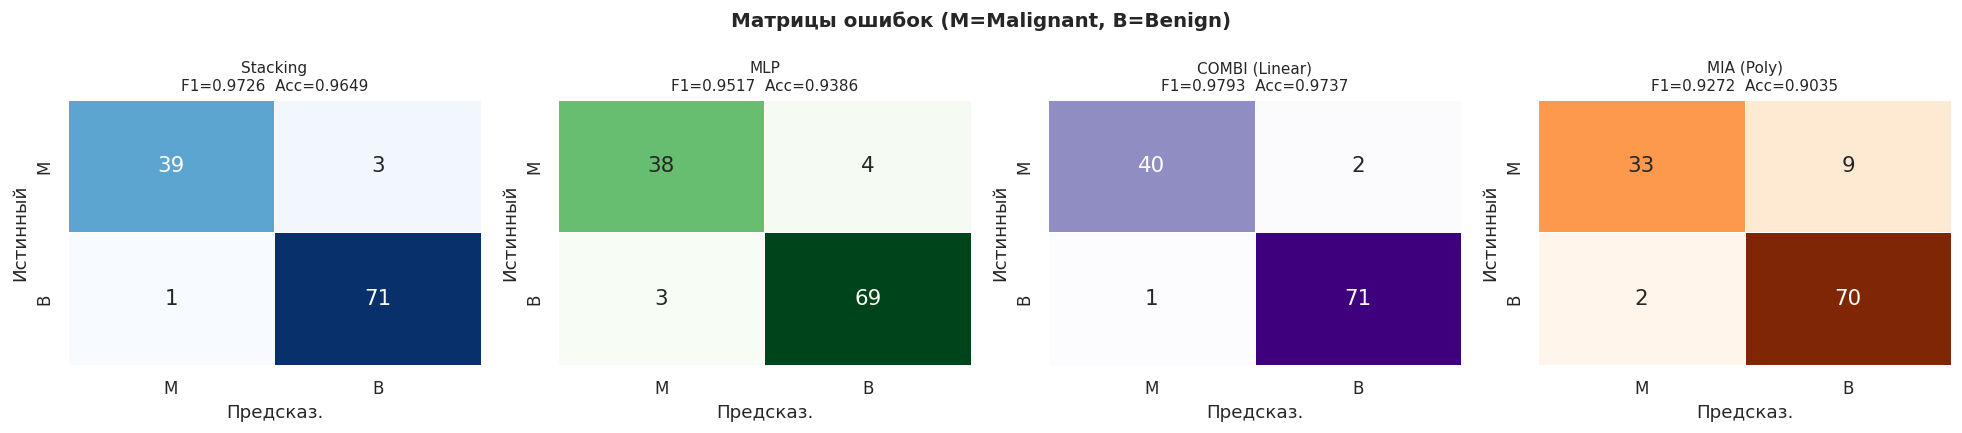

In [ ]:
# Матрицы ошибок
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
models_vis = [
    ('Stacking',       y_pred_stack, acc_stack, f1_stack, 'Blues'),
    ('MLP',            y_pred_mlp,   acc_mlp,   f1_mlp,   'Greens'),
    ('COMBI (Linear)', y_pred_combi, acc_combi, f1_combi, 'Purples'),
    ('MIA (Poly d=2)', y_pred_mia,   acc_mia,   f1_mia,   'Oranges'),
]
for ax, (name, yp, acc, f1, cmap) in zip(axes, models_vis):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['M','B'], yticklabels=['M','B'],
                linewidths=0.5, cbar=False, annot_kws={'size': 14})
    ax.set_title(f'{name}\nF1={f1:.4f}  Acc={acc:.4f}', fontsize=10)
    ax.set_ylabel('Истинный класс')
    ax.set_xlabel('Предсказанный класс')

plt.suptitle('Матрицы ошибок (M=Malignant, B=Benign)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

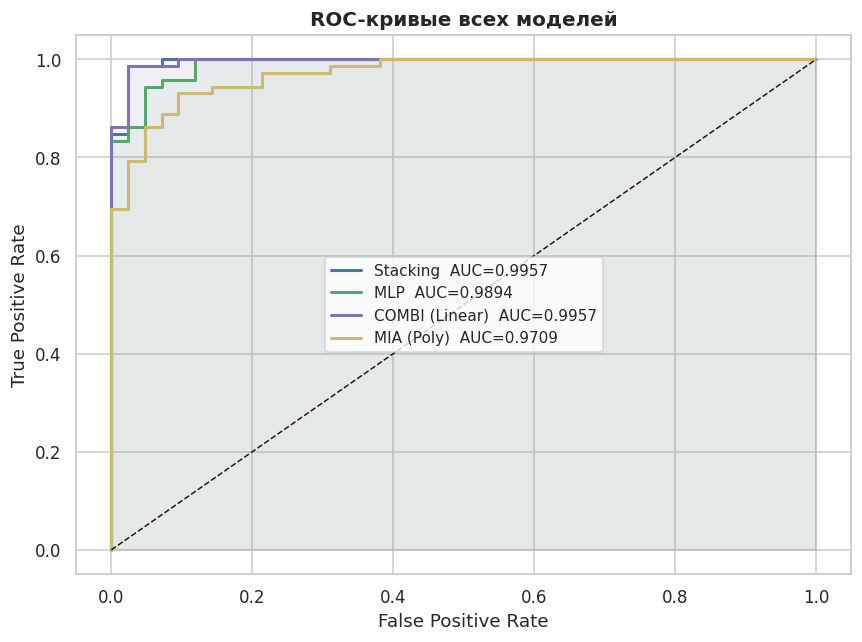

In [ ]:
# ROC-кривые
palette = ['#4C72B0', '#55A868', '#8172B2', '#CCB974']
fig, ax = plt.subplots(figsize=(9, 6))

for (name, prob, color) in zip(
    ['Stacking', 'MLP', 'COMBI (Linear)', 'MIA (Poly d=2)'],
    [y_prob_stack, y_prob_mlp, y_prob_combi, y_prob_mia],
    palette
):
    auc = roc_auc_score(y_test, prob)
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auc:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.05, color=color)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Случайный классификатор')
ax.set_title('ROC-кривые всех моделей', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Итоговая таблица и bar chart
summary = pd.DataFrame({
    'Модель':        ['Stacking', 'MLP', 'COMBI (Linear)', 'MIA (Poly d=2)'],
    'Тип':           ['Стекинг', 'Нейросеть', 'МГУА линейный', 'МГУА нелинейный'],
    'Accuracy':      [acc_stack, acc_mlp, acc_combi, acc_mia],
    'F1 Score':      [f1_stack,  f1_mlp,  f1_combi,  f1_mia],
    'ROC AUC':       [auc_stack, auc_mlp, auc_combi, auc_mia],
    'CV F1 (5-fold)':[cv_stack,  cv_mlp,  cv_combi,  cv_mia],
})
print('Итоговое сравнение моделей:')
summary

Итоговое сравнение моделей:


             Модель              Тип  Accuracy  F1 Score   ROC AUC  CV F1 (5-fold)
0          Stacking          Стекинг    0.9649    0.9726    0.9957         0.9793
1               MLP        Нейросеть    0.9386    0.9517    0.9894         0.9638
2    COMBI (Linear)    МГУА линейный    0.9737    0.9793    0.9957         0.9807
3  MIA (Poly d=2)  МГУА нелинейный    0.9035    0.9272    0.9709         0.9330


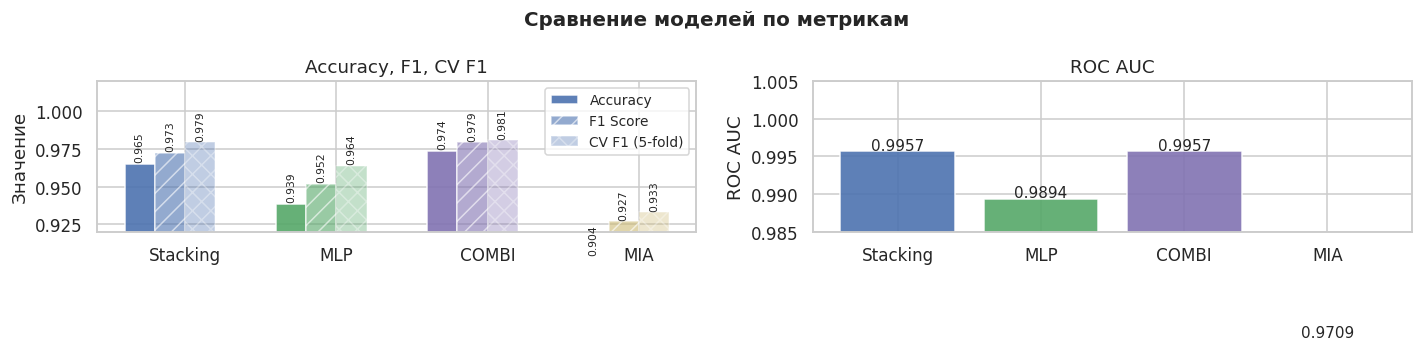

In [ ]:
# Bar chart
model_labels = ['Stacking', 'MLP', 'COMBI', 'MIA']
accs   = [acc_stack,  acc_mlp,  acc_combi,  acc_mia]
f1s    = [f1_stack,   f1_mlp,   f1_combi,   f1_mia]
aucs   = [auc_stack,  auc_mlp,  auc_combi,  auc_mia]
cv_f1s = [cv_stack,   cv_mlp,   cv_combi,   cv_mia]

x = np.arange(4)
w = 0.20
palette = ['#4C72B0', '#55A868', '#8172B2', '#CCB974']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

b1 = axes[0].bar(x - 1.5*w, accs,   w, label='Accuracy',       color=palette, alpha=0.9, edgecolor='white')
b2 = axes[0].bar(x - 0.5*w, f1s,    w, label='F1 Score',       color=palette, alpha=0.6, edgecolor='white', hatch='//')
b3 = axes[0].bar(x + 0.5*w, cv_f1s, w, label='CV F1 (5-fold)', color=palette, alpha=0.35,edgecolor='white', hatch='xx')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_labels, fontsize=11)
axes[0].set_ylim(0.88, 1.02)
axes[0].set_title('Accuracy, F1, CV F1', fontsize=12)
axes[0].set_ylabel('Значение')
axes[0].legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x()+bar.get_width()/2, h+0.001,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

axes[1].bar(model_labels, aucs, color=palette, alpha=0.9, edgecolor='white')
axes[1].set_ylim(0.960, 1.005)
axes[1].set_title('ROC AUC', fontsize=12)
axes[1].set_ylabel('ROC AUC')
for i, v in enumerate(aucs):
    axes[1].text(i, v+0.0005, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Сравнение моделей по метрикам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6. Итоговые выводы

### Сводная таблица

| Модель | Тип | F1 Score | ROC AUC | CV F1 |
|---|---|---|---|---|
| **COMBI (Linear)** | МГУА линейный | **0.9793** | **0.9957** | **0.9807** |
| **Stacking** | Стекинг | 0.9726 | **0.9957** | 0.9793 |
| MLP | Нейросеть | 0.9517 | 0.9894 | 0.9638 |
| MIA (Poly d=2) | МГУА нелинейный | 0.9272 | 0.9709 | 0.9330 |

### Ключевые выводы

1. **COMBI (логистическая регрессия)** показал наилучший F1 Score (0.9793) и наивысший CV F1 (0.9807) — данные хорошо линейно разделимы после стандартизации
2. **Stacking** занял второе место (F1=0.9726), эффективно объединив предсказания RF, SVM, KNN и DT через мета-модель. Его преимущество — устойчивость: он реже ошибается на граничных случаях
3. **MLP** с ранней остановкой сошёлся за 23 итерации, что говорит о быстрой сходимости. Показал F1=0.9517 — достаточно хороший результат, но уступает более простым моделям. Возможная причина — малый датасет (569 объектов) недостаточен для раскрытия потенциала нейросетей
4. **MIA (полиномиальные признаки degree=2)** показал наименьшее качество: генерация попарных взаимодействий привела к переобучению на ограниченном датасете. CV F1=0.9330 подтверждает слабую обобщающую способность
5. **Главный вывод:** на небольших структурированных датасетах линейные и ансамблевые методы нередко превосходят более сложные (нейросети, нелинейные МГУА). Сложность модели должна соответствовать объёму и природе данных